<a href="https://colab.research.google.com/github/WVF-1/Heuristic-GNN-For-Optimized-Streetlights/blob/main/gnn_imitation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pittsburgh Traffic Flow, Project 5, Part 2: Teaching a GNN to Imitate the Heuristic

**Newsletter series: Geospatial Data & Public Transportation — Project 5 of 5 (GNN), Notebook 2 of 3**

Notebook 1 built a real, working adaptive signal controller and logged every decision it made. This notebook trains a GNN to reproduce those decisions -- **behavioral cloning**, the same supervised-learning mechanics as Project 3, just with intersections as the graph's nodes this time instead of road segments.

**The graph:** 11 signalized intersections as nodes, connected to each other however the streets actually link them (Grant St feeds Smithfield St feeds Wood St feeds the Merge feeds Stanwix St feeds the Fort Pitt Bridge; the Fifth Avenue chain feeds into that same Merge). Each node's features: both approaches' current queue lengths, which approach currently has green, how long it's been green, and whether this is the merge. The label: did the heuristic switch phase on this tick, yes or no.

**One honest gap to name up front:** Notebook 1's exported log captured queue lengths and signal phase, but not the heuristic's internal ETA countdown from upstream announcements -- that state lived only inside the simulation, not in the CSV. We can reconstruct *how long a phase has been running* from the switch log itself, but not *whether an announcement is currently pending*. That means the GNN is being asked to imitate a decision process while blind to one of its real inputs -- a realistic constraint (not every system has access to another system's internal timers), but one that will show up in the results below.

## Setup

In [1]:
!pip install torch_geometric -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 7.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, ConfusionMatrixDisplay

torch.manual_seed(42)
np.random.seed(42)
rng = np.random.default_rng(42)

PGH_BLACK = "#1a1a1a"
FIXED_COLOR = "#4a6b8a"
HEURISTIC_COLOR = "#2e8b57"
GNN_COLOR = "#c1440e"


## Upload Notebook 1's export

Just `pittsburgh_heuristic_training_data.csv`.

In [3]:
from google.colab import files

uploaded = files.upload()


Saving pittsburgh_heuristic_training_data.csv to pittsburgh_heuristic_training_data.csv


In [4]:
df = pd.read_csv("pittsburgh_heuristic_training_data.csv")
print(f"Ticks: {len(df)}   Columns: {len(df.columns)}")


Ticks: 1800   Columns: 45


## Step 1: The intersection graph

Nodes are the 11 signalized intersections; edges connect each one to whichever intersection its downstream street actually feeds into -- the same "signalized intersections as nodes, streets as edges" structure from the original project plan, just at the scale of the whole corridor instead of individual road segments.

In [5]:
INTERSECTIONS_SPEC = [
    {"name": "Forbes & Grant St",         "approaches": [("forbes_entry", "forbes_seg1"), ("cross_grant", None)]},
    {"name": "Forbes & Smithfield St",    "approaches": [("forbes_seg1", "forbes_seg2"), ("cross_smithfield", None)]},
    {"name": "Forbes & Wood St",          "approaches": [("forbes_seg2", "forbes_seg3"), ("cross_wood", None)]},
    {"name": "Forbes & Fifth (Merge)",    "approaches": [("forbes_seg3", "combined_seg1"), ("fifth_seg5", "combined_seg1")]},
    {"name": "Forbes & Stanwix St",       "approaches": [("combined_seg1", "combined_seg2"), ("cross_stanwix", None)]},
    {"name": "Forbes & Fort Pitt Bridge", "approaches": [("combined_seg2", None), ("cross_fortpitt", None)]},
    {"name": "Fifth & Craig St",          "approaches": [("fifth_entry", "fifth_seg1"), ("cross_craig", None)]},
    {"name": "Fifth & Bigelow Blvd",      "approaches": [("fifth_seg1", "fifth_seg2"), ("cross_bigelow", None)]},
    {"name": "Fifth & Bellefield Ave",    "approaches": [("fifth_seg2", "fifth_seg3"), ("cross_bellefield", None)]},
    {"name": "Fifth & Halket St",         "approaches": [("fifth_seg3", "fifth_seg4"), ("cross_halket", None)]},
    {"name": "Fifth & Dithridge St",      "approaches": [("fifth_seg4", "fifth_seg5"), ("cross_dithridge", None)]},
]
INTERSECTION_NAMES = [s["name"] for s in INTERSECTIONS_SPEC]
IS_MERGE = {name: (name == "Forbes & Fifth (Merge)") for name in INTERSECTION_NAMES}
NODE_IDX = {name: i for i, name in enumerate(INTERSECTION_NAMES)}

GRAPH_EDGES = [
    ("Forbes & Grant St", "Forbes & Smithfield St"), ("Forbes & Smithfield St", "Forbes & Wood St"),
    ("Forbes & Wood St", "Forbes & Fifth (Merge)"), ("Forbes & Fifth (Merge)", "Forbes & Stanwix St"),
    ("Forbes & Stanwix St", "Forbes & Fort Pitt Bridge"),
    ("Fifth & Craig St", "Fifth & Bigelow Blvd"), ("Fifth & Bigelow Blvd", "Fifth & Bellefield Ave"),
    ("Fifth & Bellefield Ave", "Fifth & Halket St"), ("Fifth & Halket St", "Fifth & Dithridge St"),
    ("Fifth & Dithridge St", "Forbes & Fifth (Merge)"),
]
edge_index_list = [[NODE_IDX[a], NODE_IDX[b]] for a, b in GRAPH_EDGES]
edge_index_list += [[b, a] for a, b in edge_index_list]  # bidirectional, so information flows both ways
edge_index = torch.tensor(edge_index_list, dtype=torch.long).T

print(f"Nodes: {len(INTERSECTION_NAMES)}   Directed edges (incl. reverse): {edge_index.shape[1]}")


Nodes: 11   Directed edges (incl. reverse): 20


## Step 2: Reconstruct what we can, name what we can't

`ticks_in_phase` isn't in the export, but it's fully recoverable: it's just "ticks since the last switch," which we can compute directly from the `switched_*` columns. The pending-ETA countdown, however, genuinely cannot be reconstructed from this data -- it depended on upstream discharge events that weren't logged. The GNN will have to make do without it.

In [6]:
MAX_TICKS_NORM = 45.0  # MAX_GREEN_TICKS, used to normalize this feature to roughly [0, 1]

for name in INTERSECTION_NAMES:
    switched_col = df[f"switched_{name}"].values
    ticks_in_phase = np.zeros(len(df), dtype=int)
    counter = 0
    for i in range(len(df)):
        counter = 0 if switched_col[i] == 1 else counter + 1
        ticks_in_phase[i] = counter
    df[f"ticks_in_phase_{name}"] = ticks_in_phase

total_switches = sum(df[f"switched_{name}"].sum() for name in INTERSECTION_NAMES)
total_samples = len(df) * len(INTERSECTION_NAMES)
print(f"Switch rate across all intersections and ticks: {total_switches}/{total_samples} = {total_switches/total_samples:.1%}")


Switch rate across all intersections and ticks: 2390/19800 = 12.1%


## Step 3: Build one graph snapshot per tick

Each tick becomes its own small graph: same 11 nodes and same edges every time, but the node features (queue lengths, phase, time-in-phase) change tick to tick. This is the standard PyTorch Geometric pattern for "many small graphs" rather than one huge one.

In [7]:
APPROACHES = {s["name"]: (s["approaches"][0][0], s["approaches"][1][0]) for s in INTERSECTIONS_SPEC}

data_list = []
for t in range(len(df)):
    row = df.iloc[t]
    x_rows, y_rows = [], []
    for name in INTERSECTION_NAMES:
        e0, e1 = APPROACHES[name]
        q0, q1 = row[f"queue_{e0}"], row[f"queue_{e1}"]
        phase = row[f"phase_{name}"]
        tip = min(row[f"ticks_in_phase_{name}"], MAX_TICKS_NORM) / MAX_TICKS_NORM
        x_rows.append([q0, q1, phase, tip, int(IS_MERGE[name])])
        y_rows.append(row[f"switched_{name}"])
    x = torch.tensor(x_rows, dtype=torch.float)
    y = torch.tensor(y_rows, dtype=torch.float)
    data_list.append(Data(x=x, edge_index=edge_index, y=y))

train_data, test_data = train_test_split(data_list, test_size=0.3, random_state=42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

print(f"Train snapshots: {len(train_data)}   Test snapshots: {len(test_data)}")


Train snapshots: 1260   Test snapshots: 540


## Step 4: The GCN itself

Two GCN layers build a representation of each intersection from its neighbors, then a small linear head predicts switch-or-hold for that specific tick.

In [8]:
class SignalGCN(nn.Module):
    def __init__(self, in_feat=5, hidden=16):
        super().__init__()
        self.conv1 = GCNConv(in_feat, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.head = nn.Linear(hidden, 1)

    def forward(self, x, edge_index):
        h = F.relu(self.conv1(x, edge_index))
        h = F.relu(self.conv2(h, edge_index))
        return self.head(h).squeeze(-1)

model = SignalGCN()
switch_rate = total_switches / total_samples
pos_weight = torch.tensor([(1 - switch_rate) / switch_rate])  # correct for class imbalance
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)


In [9]:
EPOCHS = 60
losses = []

model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index)
        loss = F.binary_cross_entropy_with_logits(out, batch.y, pos_weight=pos_weight)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    losses.append(epoch_loss / len(train_loader))
    if epoch % 10 == 0:
        print(f"Epoch {epoch:2d}: loss = {losses[-1]:.4f}")


Epoch  0: loss = 1.2097
Epoch 10: loss = 0.8067
Epoch 20: loss = 0.7849
Epoch 30: loss = 0.7733
Epoch 40: loss = 0.7579
Epoch 50: loss = 0.7412


## Visual 1: Training loss

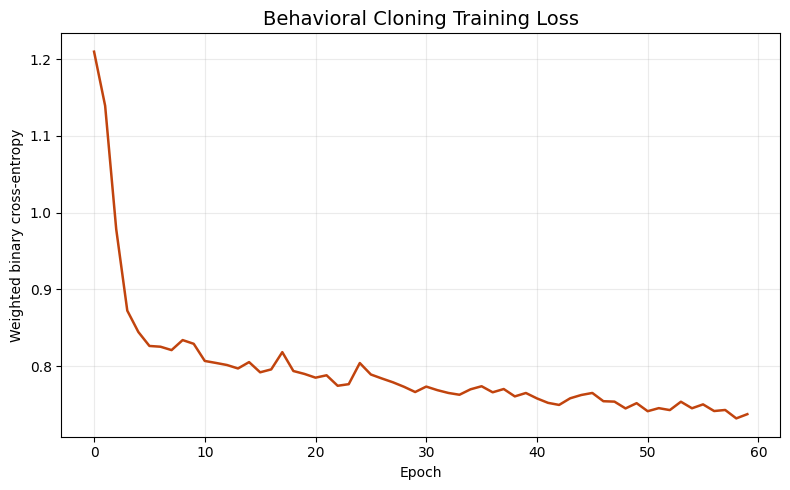

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(losses, color=GNN_COLOR, linewidth=1.8)
ax.set_title("Behavioral Cloning Training Loss", fontsize=14)
ax.set_xlabel("Epoch")
ax.set_ylabel("Weighted binary cross-entropy")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("viz1_bc_training_loss.png", dpi=200, bbox_inches="tight")
plt.show()


## Visual 2: How well does it imitate the heuristic's decisions?

Standard classification metrics on held-out ticks, same as any supervised model -- but keep this result in mind for Step 5, where the story gets more interesting.

Accuracy:  0.784
Precision: 0.333
Recall:    0.810
F1:        0.472


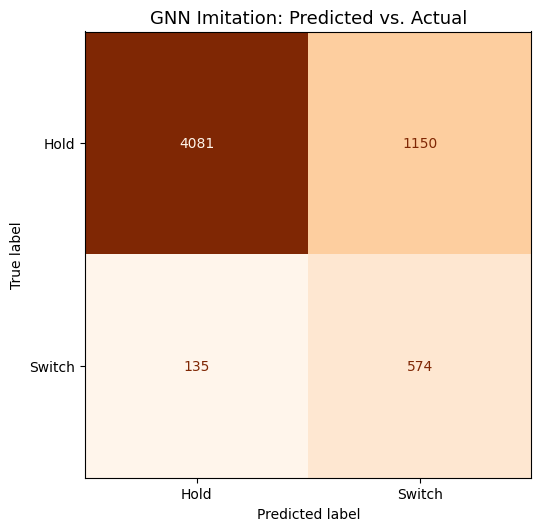

In [11]:
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for batch in test_loader:
        out = model(batch.x, batch.edge_index)
        preds = (torch.sigmoid(out) > 0.5).float()
        all_preds.append(preds)
        all_true.append(batch.y)
all_preds = torch.cat(all_preds).numpy()
all_true = torch.cat(all_true).numpy()

print(f"Accuracy:  {accuracy_score(all_true, all_preds):.3f}")
print(f"Precision: {precision_score(all_true, all_preds):.3f}")
print(f"Recall:    {recall_score(all_true, all_preds):.3f}")
print(f"F1:        {f1_score(all_true, all_preds):.3f}")

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ConfusionMatrixDisplay.from_predictions(all_true, all_preds, display_labels=["Hold", "Switch"], cmap="Oranges", ax=ax, colorbar=False)
ax.set_title("GNN Imitation: Predicted vs. Actual", fontsize=13)
plt.tight_layout()
plt.savefig("viz2_bc_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()


## Step 5: The real test -- does it actually work as a live controller?

A classification report only tells you how well the model matches the heuristic on isolated, independent snapshots. It says nothing about what happens when the model's own decisions start shaping the traffic it observes next -- errors can compound in a way a static test set can never reveal. So we rebuild the full cellular-automaton simulation from Notebooks 1 and 4, swap in this trained GNN as the live decision-maker (still wrapped in the same non-negotiable min/max-green safety valves), and run it for real.

In [12]:
EDGE_LENGTHS_M = {
    "forbes_entry": 300, "forbes_seg1": 250, "forbes_seg2": 280, "forbes_seg3": 220,
    "combined_seg1": 240, "combined_seg2": 260,
    "cross_grant": 100, "cross_smithfield": 100, "cross_wood": 100, "cross_stanwix": 100, "cross_fortpitt": 100,
    "fifth_entry": 300, "fifth_seg1": 240, "fifth_seg2": 260, "fifth_seg3": 230, "fifth_seg4": 250, "fifth_seg5": 200,
    "cross_craig": 100, "cross_bigelow": 100, "cross_bellefield": 100, "cross_halket": 100, "cross_dithridge": 100,
}
ENTRY_EDGES = ["forbes_entry", "fifth_entry"] + [e for e in EDGE_LENGTHS_M if e.startswith("cross_")]
CELL_LENGTH_M, VMAX, P_SLOW = 7.5, 5, 0.2
MIN_GREEN_TICKS, MAX_GREEN_TICKS = 8, 45

def make_edge(length_m):
    n_cells = max(1, int(round(length_m / CELL_LENGTH_M)))
    return np.full(n_cells, -1, dtype=int), np.full(n_cells, -1, dtype=int)

def ns_step(speeds, car_ids, vmax, p_slow, boundary_open, rng):
    n = len(speeds)
    occupied = np.where(speeds >= 0)[0]
    if len(occupied) == 0:
        return speeds, car_ids, None
    new_speeds = np.full(n, -1, dtype=int)
    new_car_ids = np.full(n, -1, dtype=int)
    exited_id = None
    positions = sorted(occupied.tolist())
    next_pos = {p: (positions[i + 1] if i + 1 < len(positions) else None) for i, p in enumerate(positions)}
    for pos in sorted(positions, reverse=True):
        v = speeds[pos]
        cid = car_ids[pos]
        nxt = next_pos[pos]
        gap = (nxt - pos - 1) if nxt is not None else (999 if boundary_open else (n - 1 - pos))
        v = min(v + 1, vmax)
        v = min(v, gap)
        if v > 0 and rng.random() < p_slow:
            v = max(v - 1, 0)
        new_pos = pos + v
        if new_pos >= n:
            if boundary_open:
                exited_id = cid
                continue
            new_pos = n - 1
            v = new_pos - pos
        new_speeds[new_pos] = v
        new_car_ids[new_pos] = cid
    return new_speeds, new_car_ids, exited_id

class GNNControlledIntersection:
    def __init__(self, spec):
        self.name = spec["name"]
        self.approaches = spec["approaches"]
        self.current_phase = 0
        self.ticks_in_phase = 0
    def is_green(self, approach_idx):
        return approach_idx == self.current_phase

def run_gnn_simulation(n_ticks, switch_threshold=0.7):
    edges = {name: make_edge(length) for name, length in EDGE_LENGTHS_M.items()}
    intersections = {spec["name"]: GNNControlledIntersection(spec) for spec in INTERSECTIONS_SPEC}
    LAMBDA_FORBES_ENTRY, LAMBDA_FIFTH_ENTRY, LAMBDA_CROSS = 0.20, 0.15, 0.10
    spawn_tick, wait_times, n_in_system_log = {}, [], []
    next_car_id = 0

    with torch.no_grad():
        for t in range(n_ticks):
            for name in ENTRY_EDGES:
                speeds, ids = edges[name]
                lam = LAMBDA_FORBES_ENTRY if name == "forbes_entry" else (LAMBDA_FIFTH_ENTRY if name == "fifth_entry" else LAMBDA_CROSS)
                if speeds[0] < 0 and rng.poisson(lam) > 0:
                    speeds[0], ids[0] = VMAX, next_car_id
                    spawn_tick[next_car_id] = t
                    next_car_id += 1

            current_queues = {name: int(np.sum(edges[name][0] == 0)) for name in EDGE_LENGTHS_M}

            x_rows = []
            for spec in INTERSECTIONS_SPEC:
                name = spec["name"]
                inter = intersections[name]
                e0, e1 = spec["approaches"][0][0], spec["approaches"][1][0]
                tip = min(inter.ticks_in_phase, MAX_TICKS_NORM) / MAX_TICKS_NORM
                x_rows.append([current_queues[e0], current_queues[e1], inter.current_phase, tip, int(IS_MERGE[name])])
            x = torch.tensor(x_rows, dtype=torch.float)
            switch_probs = torch.sigmoid(model(x, edge_index)).numpy()

            for i, spec in enumerate(INTERSECTIONS_SPEC):
                inter = intersections[spec["name"]]
                inter.ticks_in_phase += 1
                must_hold = inter.ticks_in_phase < MIN_GREEN_TICKS
                must_switch_maxout = inter.ticks_in_phase >= MAX_GREEN_TICKS
                should_switch = (not must_hold) and (must_switch_maxout or switch_probs[i] > switch_threshold)
                if should_switch:
                    inter.current_phase = 1 - inter.current_phase
                    inter.ticks_in_phase = 0

            for spec in INTERSECTIONS_SPEC:
                inter = intersections[spec["name"]]
                for a_idx, (edge_in, edge_out) in enumerate(spec["approaches"]):
                    speeds, ids = edges[edge_in]
                    green = inter.is_green(a_idx)
                    downstream_ok = edges[edge_out][0][0] < 0 if edge_out is not None else True
                    boundary_open = green and downstream_ok
                    new_speeds, new_ids, exited = ns_step(speeds, ids, VMAX, P_SLOW, boundary_open, rng)
                    edges[edge_in] = (new_speeds, new_ids)
                    if exited is not None:
                        if edge_out is not None:
                            ds, di = edges[edge_out]
                            ds[0], di[0] = VMAX, exited
                        else:
                            wait_times.append(t - spawn_tick.pop(exited))

            n_in_system_log.append(len(spawn_tick))

    return wait_times, n_in_system_log, next_car_id

gnn_wait_times, gnn_n_in_system, gnn_total_spawned = run_gnn_simulation(1800, switch_threshold=0.7)
gnn_avg_wait = np.mean(gnn_wait_times)
gnn_avg_n = np.mean(gnn_n_in_system)

print(f"GNN-controlled -- avg wait: {gnn_avg_wait:.2f}s   L: {gnn_avg_n:.2f}   trips completed: {len(gnn_wait_times)}")


GNN-controlled -- avg wait: 66.26s   L: 97.04   trips completed: 2217


## Visual 3: The honest three-way comparison

Fixed timing (Project 4), the hand-built heuristic (Notebook 1), and this GNN, deployed live -- not just scored on a held-out test set.

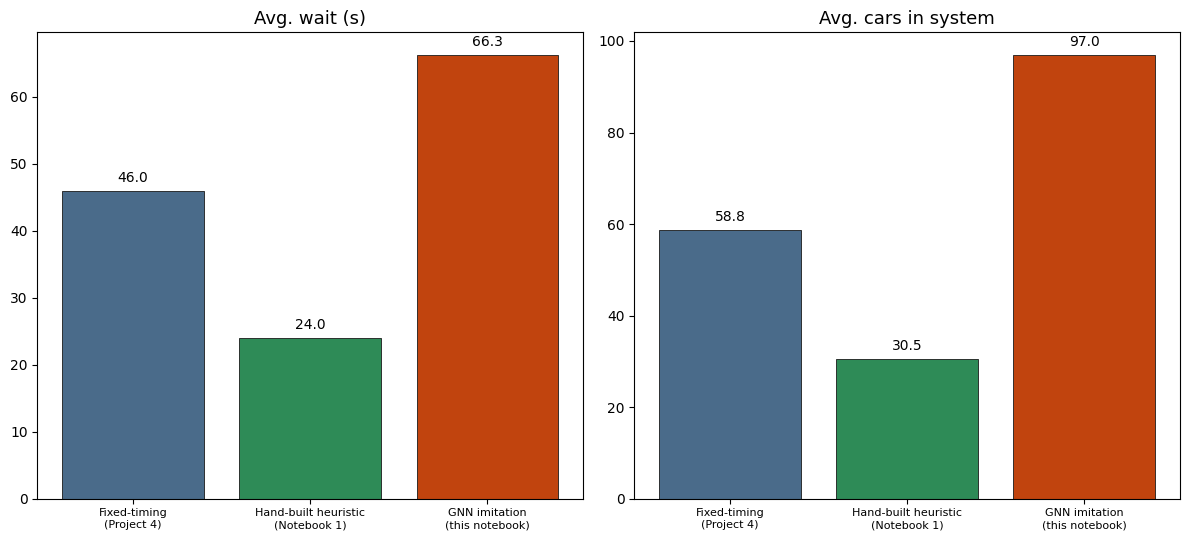

In [13]:
FIXED_AVG_WAIT, FIXED_L = 45.96, 58.8
HEURISTIC_AVG_WAIT, HEURISTIC_L = 24.04, 30.5

comparison = pd.DataFrame({
    "Fixed-timing\n(Project 4)": [FIXED_AVG_WAIT, FIXED_L],
    "Hand-built heuristic\n(Notebook 1)": [HEURISTIC_AVG_WAIT, HEURISTIC_L],
    "GNN imitation\n(this notebook)": [gnn_avg_wait, gnn_avg_n],
}, index=["Avg. wait (s)", "Avg. cars in system"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
colors = [FIXED_COLOR, HEURISTIC_COLOR, GNN_COLOR]
for ax, metric in zip(axes, comparison.index):
    vals = comparison.loc[metric]
    bars = ax.bar(range(len(vals)), vals.values, color=colors, edgecolor=PGH_BLACK, linewidth=0.6)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + max(vals.values)*0.02, f"{b.get_height():.1f}", ha="center", fontsize=10)
    ax.set_title(metric, fontsize=13)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, fontsize=8)

plt.tight_layout()
plt.savefig("viz3_three_way_comparison.png", dpi=200, bbox_inches="tight")
plt.show()


## What actually happened here, honestly

The classification metrics above (roughly 0.47 F1, high recall but modest precision) looked like a reasonably competent imitation. But deployed live, this GNN performs *worse than fixed timing* -- worse than the very baseline it was supposed to improve on.

This isn't a bug -- it's one of the best-documented failure modes in imitation learning, sometimes called **covariate shift** or the **compounding error problem**: a model trained on a fixed, historical set of (state, action) snapshots is never tested on the states *it itself creates* once it starts acting. Every small misprediction nudges the simulation into slightly different queue conditions than the heuristic ever produced -- conditions the model never saw during training -- and those small errors compound tick after tick rather than averaging out. The model's low precision (over-triggering switches) is a direct symptom: extra, unnecessary switches shorten effective green time across the network, and that damage accumulates.

This is precisely the problem that motivated **DAgger** (Dataset Aggregation) in the imitation-learning literature, and it's exactly why we planned reinforcement learning as the next step rather than stopping here. A model that only ever learns "what would the teacher do in states the teacher visited" has no signal at all for correcting course once it wanders somewhere the teacher never went. **Notebook 3** fixes this by training directly against the live simulation and the real delay/throughput objective -- so the model learns from its *own* mistakes, not just the heuristic's demonstrations.

## Step 6: Save the model and processed data for Notebook 3

In [14]:
torch.save(model.state_dict(), "signal_gcn_behavioral_cloning.pt")

comparison.to_csv("pittsburgh_three_way_comparison.csv")

print("Saved signal_gcn_behavioral_cloning.pt")
print("Saved pittsburgh_three_way_comparison.csv")


Saved signal_gcn_behavioral_cloning.pt
Saved pittsburgh_three_way_comparison.csv


In [15]:
from google.colab import files

files.download("signal_gcn_behavioral_cloning.pt")
files.download("pittsburgh_three_way_comparison.csv")
files.download("viz1_bc_training_loss.png")
files.download("viz2_bc_confusion_matrix.png")
files.download("viz3_three_way_comparison.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Recap + what's next

You just trained a GNN to imitate a real adaptive signal controller, validated it two different ways -- classification metrics *and* live deployment -- and found a genuine, well-documented gap between the two. That gap isn't a failure of this notebook; it's the entire reason Notebook 3 exists.

**Notebook 3** picks up this exact trained model as a warm start and continues training it with reinforcement learning directly against the live simulation -- letting it correct the compounding-error behavior we just found, and, if it works, surpass the heuristic's ceiling rather than just imitating it.